# 🚗 Used Car Dynamic Valuation Engine - Comprehensive EDA & Feature Engineering

**Dataset:** CarDekho Used Car Dataset (8,128 vehicles)
**Business Objective:** Uncover pricing drivers, expose string unit parsing traps (`mileage`, `engine`, `max_power`), analyze high-cardinality brand distributions, and establish the feature engineering pipeline.

### 1. Import Essential Libraries & Setup Visuals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


### 2. Load Raw Dataset & Inspect Structure

In [ ]:
df = pd.read_csv('../Data/Raw/Car details v3.csv')
print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset Shape: 8128 rows, 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


### 3. Missing Value & Trap Audit
Notice how `mileage`, `engine`, and `max_power` are stored as `object` strings with units like `'kmpl'`, `'CC'`, and `'bhp'`. Furthermore, there are ~221 missing values.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing %
mileage,221,2.718996
engine,221,2.718996
max_power,215,2.645177
torque,222,2.731299
seats,221,2.718996


### 4. Data Cleaning: Extracting Numeric Values from Text Units
- `mileage`: extract float (e.g. `'23.4 kmpl'` -> `23.4`)
- `engine`: extract float (e.g. `'1248 CC'` -> `1248`)
- `max_power`: extract float (e.g. `'74 bhp'` -> `74.0`)
- Extract `brand` from `name` (e.g. `'Maruti Swift Dzire VDI'` -> `'Maruti'`)

In [5]:
# Extract numeric values using regex string extraction
df['mileage_kmpl'] = df['mileage'].str.extract(r'([0-9.]+)', expand=False).astype(float)
df['engine_cc'] = df['engine'].str.extract(r'([0-9.]+)', expand=False).astype(float)
df['max_power_bhp'] = df['max_power'].str.extract(r'([0-9.]+)', expand=False).astype(float)

# Extract car brand as the first word of car name
df['brand'] = df['name'].apply(lambda x: str(x).split()[0].strip())

# Drop torque (very noisy unstructured string e.g. '190Nm@ 2000rpm')
df = df.drop(columns=['torque', 'mileage', 'engine', 'max_power'])
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,Maruti


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   seats          7907 non-null   float64
 9   mileage_kmpl   7907 non-null   float64
 10  engine_cc      7907 non-null   float64
 11  max_power_bhp  7912 non-null   float64
 12  brand          8128 non-null   str    
 13  car_age        8128 non-null   int64  
 14  km_per_year    8128 non-null   float64
dtypes: float64(5), int64(4), str(6)
memory usage: 1.4 MB


### 5. Target Variable Analysis: `selling_price` Skewness
Let's visualize the raw selling price distribution vs log-transformed price.

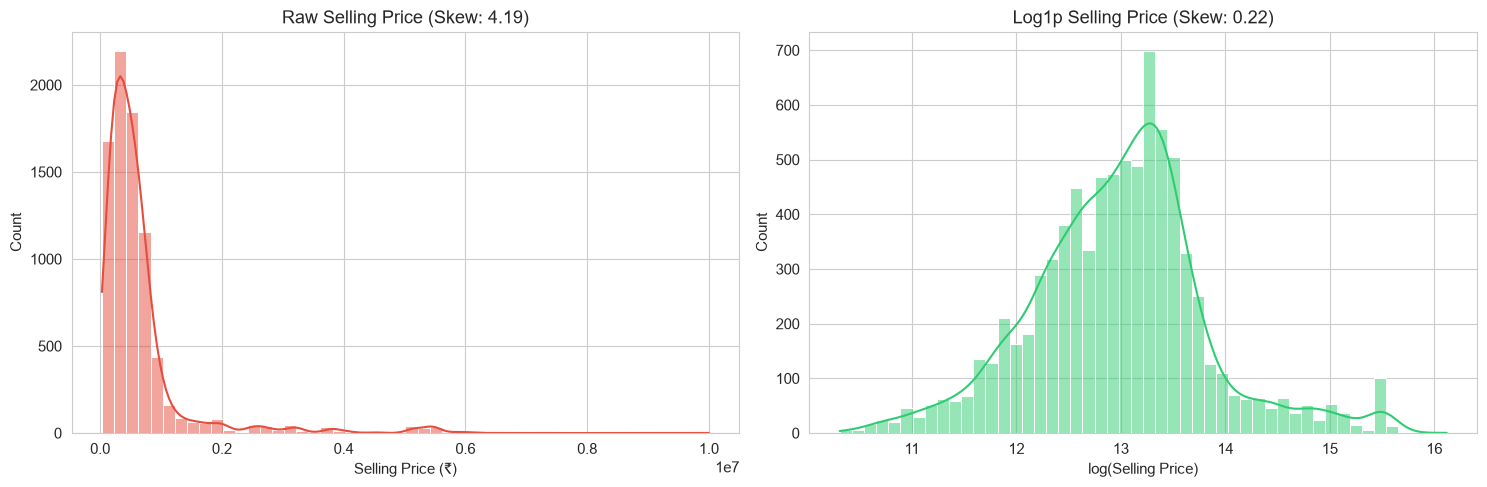

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['selling_price'], kde=True, color='#e74c3c', bins=50, ax=axes[0])
axes[0].set_title(f'Raw Selling Price (Skew: {df["selling_price"].skew():.2f})')
axes[0].set_xlabel('Selling Price (₹)')

log_price = np.log1p(df['selling_price'])
sns.histplot(log_price, kde=True, color='#2ecc71', bins=50, ax=axes[1])
axes[1].set_title(f'Log1p Selling Price (Skew: {log_price.skew():.2f})')
axes[1].set_xlabel('log(Selling Price)')

plt.tight_layout()
plt.show()

💡 **Key Target Insight:** Raw selling price is extremely right-skewed (skewness > 4.1). Training on raw prices will cause models to bias heavily towards ultra-luxury cars. Using `np.log1p(selling_price)` gives a clean bell-curve Gaussian distribution!

### 6. Feature Engineering: Domain Signals
1. **`car_age`** = Reference Year (2024) - `year`
2. **`km_per_year`** = `km_driven` / (`car_age` + 0.1)
3. **`depreciation_ratio`** = Exponential decay curve

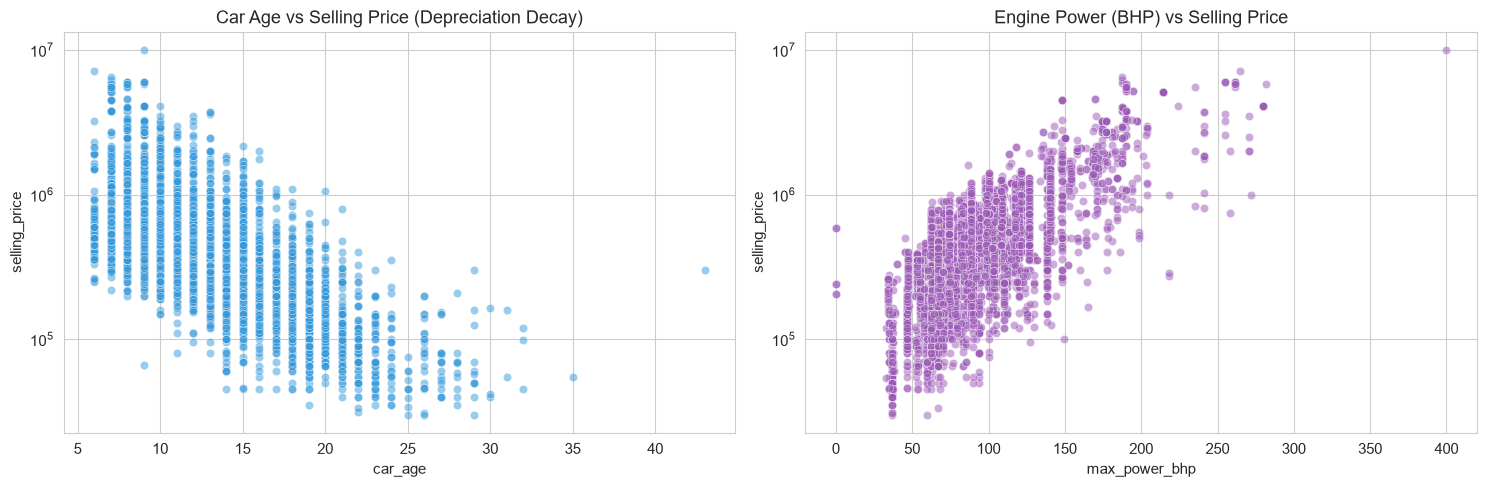

In [12]:
df['car_age'] = 2026 - df['year']
df['km_per_year'] = df['km_driven'] / (df['car_age'] + 0.5)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='car_age', y='selling_price', alpha=0.5, color='#3498db', ax=ax[0])
ax[0].set_title('Car Age vs Selling Price (Depreciation Decay)')
ax[0].set_yscale('log')

sns.scatterplot(data=df, x='max_power_bhp', y='selling_price', alpha=0.5, color='#9b59b6', ax=ax[1])
ax[1].set_title('Engine Power (BHP) vs Selling Price')
ax[1].set_yscale('log')
plt.tight_layout()
plt.show()

### 7. Brand Analysis: High Cardinality & Brand Prestige

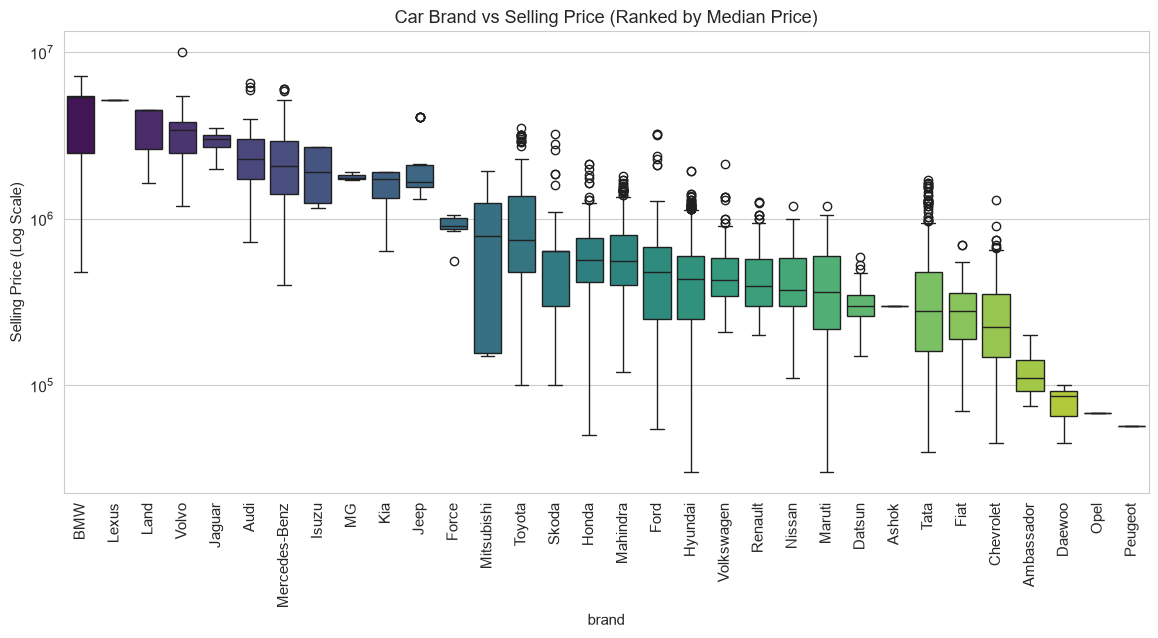

In [8]:
plt.figure(figsize=(14, 6))
brand_order = df.groupby('brand')['selling_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='brand', y='selling_price', order=brand_order, palette='viridis')
plt.xticks(rotation=90)
plt.yscale('log')
plt.title('Car Brand vs Selling Price (Ranked by Median Price)')
plt.ylabel('Selling Price (Log Scale)')
plt.show()

💡 **Brand Insights:**
- Luxury brands (BMW, Volvo, Land Rover, Jaguar, Audi, Mercedes) command a 5x-10x price premium.
- Mass-market brands (Maruti, Hyundai, Tata, Honda) make up >70% of total marketplace volume.
- Target Encoding or grouped frequency encoding on `brand` will be vastly superior to 32 dummy One-Hot columns.

### 8. Fuel Type, Transmission, and Owner Dynamics

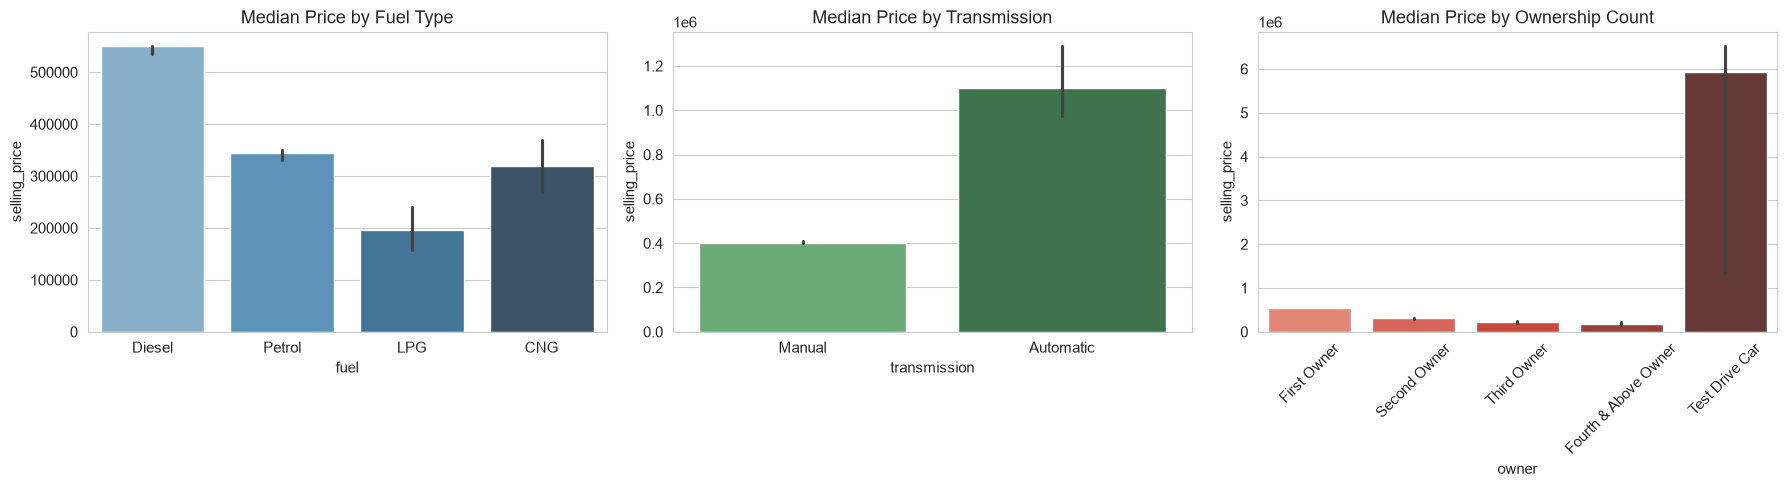

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='fuel', y='selling_price', estimator=np.median, palette='Blues_d', ax=axes[0])
axes[0].set_title('Median Price by Fuel Type')

sns.barplot(data=df, x='transmission', y='selling_price', estimator=np.median, palette='Greens_d', ax=axes[1])
axes[1].set_title('Median Price by Transmission')

owner_order = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']
sns.barplot(data=df, x='owner', y='selling_price', estimator=np.median, order=owner_order, palette='Reds_d', ax=axes[2])
axes[2].set_title('Median Price by Ownership Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

💡 **Marketplace Insights:**
- **Transmission**: Automatic cars sell for more than **2x the median price** of manual cars.
- **Fuel**: Diesel cars have significantly higher resale value than Petrol or CNG.
- **Ownership**: Sharp progressive drop in price from First Owner to Third/Fourth Owner.

### 9. Numerical Feature Correlation Matrix

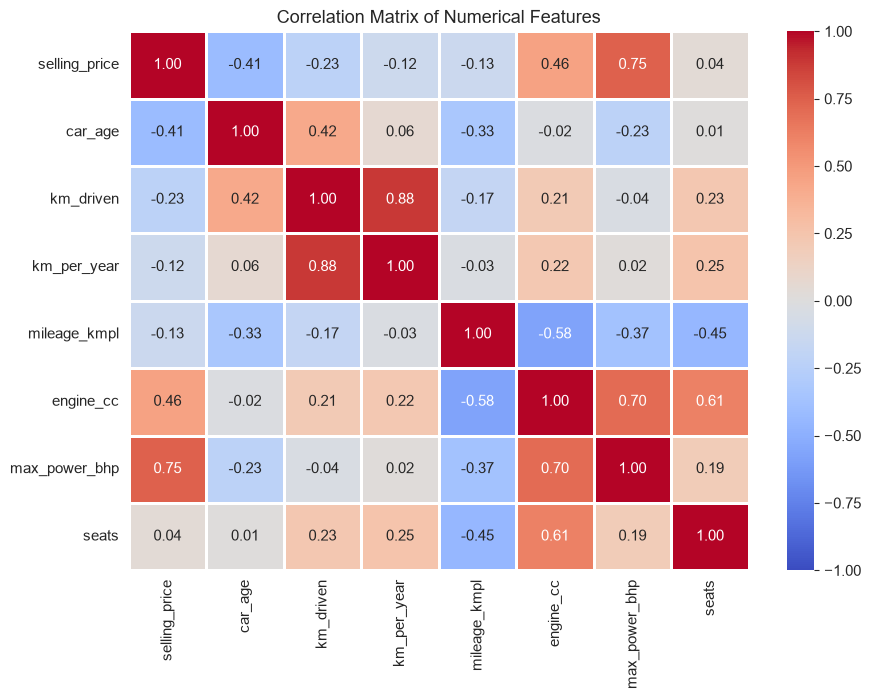

In [10]:
num_cols = ['selling_price', 'car_age', 'km_driven', 'km_per_year', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 10. Blueprint for Production Pipeline Architecture
1. **Drop `torque` & `name`**: `torque` is noisy unformatted text; `name` high cardinality will be represented by `brand`.
2. **Numeric Feature Extraction**: Extract floats for `mileage_kmpl`, `engine_cc`, and `max_power_bhp`.
3. **Domain Features**: Compute `car_age` and `km_per_year`.
4. **Pipeline Imputation**: Impute missing numericals with `median`, categoricals with `most_frequent`.
5. **Target Transformation**: `y = np.log1p(selling_price)` during training, and `np.expm1` during prediction.
6. **Evaluation Metric**: Focus on **MAPE < 12%** and **$R^2$ > 0.85** on test split.